# Notebook 03 — Regression Model & Feature Importance

**Input:** `public/data/panel.json`
**Output:** `public/data/regression.json` — model results for the dashboard's Drivers tab

This notebook:
1. Fits an OLS regression predicting `days_to_feed` from commodity prices, wages, CPI, and household size
2. Runs diagnostics (VIF, normality, heteroscedasticity)
3. Computes standardized coefficients for feature importance
4. Exports results to `regression.json`

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

PANEL_PATH = Path("../public/data/panel.json")
OUTPUT = Path("../public/data/regression.json")

with open(PANEL_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Panel: {df.shape[0]} rows, {df['region'].nunique()} regions")
df.head()

Panel: 1700 rows, 17 regions


,region,month,rice_price,rice_wm_price,egg_price,fish_price,pork_price,cpi_all,cpi_b30,daily_wage,household_size,daily_basket_pp,daily_basket_hh,monthly_basket,days_to_feed,real_wage,rice_share,wage_basket_gap
0,NCR,2018-01,37.26,43.80,5.77,159.84,262.34,96.9,96.7,500.0,3.83,86.8000,332.4440,9973.3200,19.9466,515.9959,0.1717,167.5560
1,NCR,2018-02,37.42,43.94,5.76,161.74,265.17,98.0,97.7,500.0,3.83,87.6675,335.7665,10072.9958,20.1460,510.2041,0.1707,164.2335
2,NCR,2018-03,38.03,44.17,5.61,171.16,265.40,99.0,98.9,500.0,3.83,89.8150,343.9914,10319.7435,20.6395,505.0505,0.1694,156.0086
3,NCR,2018-04,38.07,44.19,5.49,172.32,265.87,99.3,99.1,500.0,3.83,90.1215,345.1653,10354.9604,20.7099,503.5247,0.1690,154.8347
4,NCR,2018-05,37.92,44.34,5.36,169.98,267.56,99.2,98.9,500.0,3.83,89.8340,344.0642,10321.9266,20.6439,504.0323,0.1688,155.9358


## 1. OLS Regression

Predict `days_to_feed` from commodity prices, minimum wage, CPI, and household size.

In [2]:
features = ["rice_price", "egg_price", "fish_price", "pork_price",
            "daily_wage", "cpi_b30", "household_size"]
target = "days_to_feed"

model_df = df[features + [target]].dropna()
print(f"Model data: {len(model_df)} rows (dropped {len(df) - len(model_df)} with NaN)")

X = model_df[features]
y = model_df[target]
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())

Model data: 1700 rows (dropped 0 with NaN)
                            OLS Regression Results                            
Dep. Variable:           days_to_feed   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                 1.182e+04
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        23:06:28   Log-Likelihood:                -2147.3
No. Observations:                1700   AIC:                             4311.
Df Residuals:                    1692   BIC:                             4354.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
c

## 2. Diagnostics

### 2a. Variance Inflation Factor (Multicollinearity)

In [3]:
vif_data = pd.DataFrame({
    "Feature": features,
    "VIF": [variance_inflation_factor(X_const.values, i + 1) for i in range(len(features))]
})
vif_data = vif_data.sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF > 10 indicates problematic multicollinearity):")
print(vif_data.to_string(index=False))

Variance Inflation Factors (VIF > 10 indicates problematic multicollinearity):
       Feature      VIF
       cpi_b30 8.335671
     egg_price 4.569604
    pork_price 3.652619
    fish_price 3.167019
    daily_wage 2.439153
household_size 1.813721
    rice_price 1.668776


### 2b. Residual Normality & Heteroscedasticity

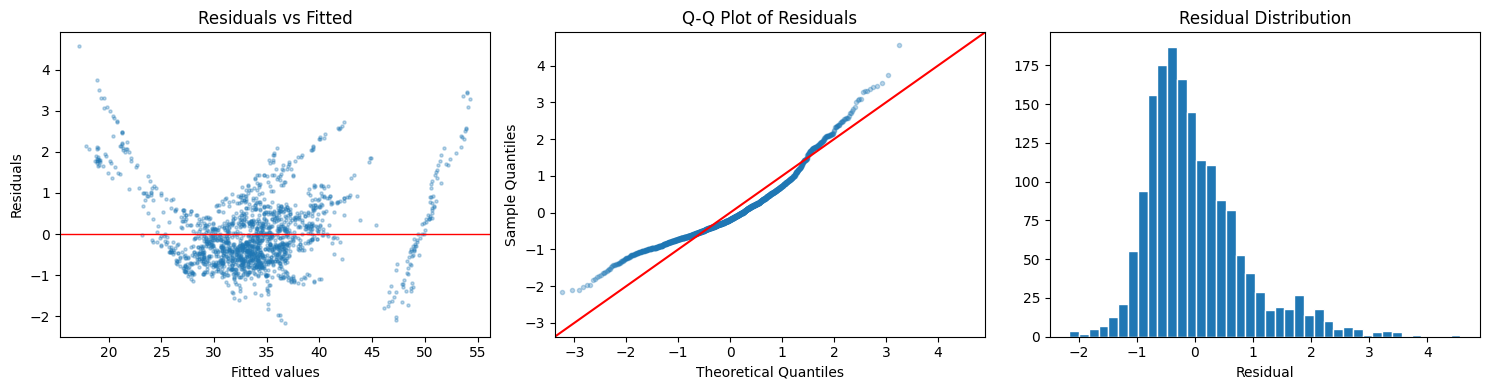

Jarque-Bera test: stat=711.09, p=0.0000
  → Non-normal residuals (at α=0.05)
Durbin-Watson: 0.122 (2.0 = no autocorrelation)


In [4]:
import matplotlib.pyplot as plt

residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, s=5, alpha=0.3)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q plot
sm.qqplot(residuals, line="45", ax=axes[1], markersize=3, alpha=0.3)
axes[1].set_title("Q-Q Plot of Residuals")

# Histogram of residuals
axes[2].hist(residuals, bins=40, edgecolor="white")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")

fig.tight_layout()
plt.show()

# Statistical tests
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"Jarque-Bera test: stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"  → {'Normal' if jb_p > 0.05 else 'Non-normal'} residuals (at α=0.05)")

dw = sm.stats.stattools.durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.3f} (2.0 = no autocorrelation)")

## 3. Feature Importance (Standardized Coefficients)

Standardize all features to z-scores, then refit. The resulting coefficients are directly comparable in magnitude.

Feature Importance (by |standardized coefficient|):
 rank        feature  std_coef      p_value  significant
    1     daily_wage -0.922565 0.000000e+00         True
    2 household_size  0.683706 0.000000e+00         True
    3     fish_price  0.464508 0.000000e+00         True
    4     pork_price  0.448334 0.000000e+00         True
    5     rice_price  0.083261 2.728944e-71         True
    6      egg_price -0.082833 2.037994e-28         True
    7        cpi_b30 -0.026026 8.880092e-03         True


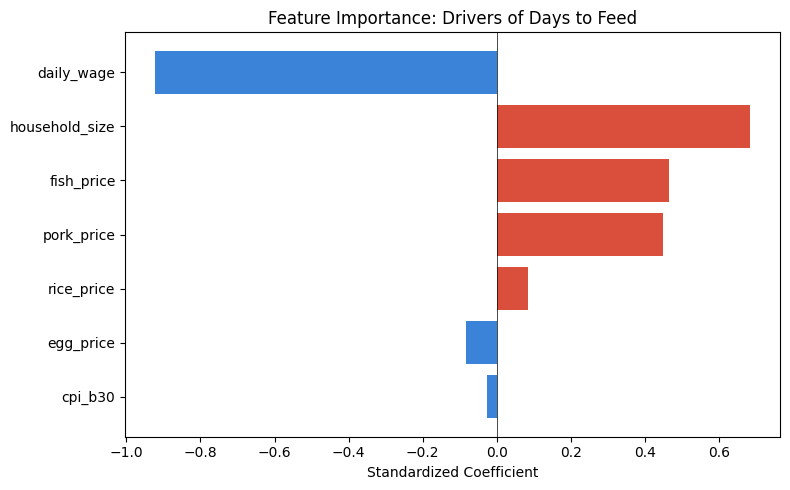

In [5]:
# Standardize features and target
X_std = (X - X.mean()) / X.std()
y_std = (y - y.mean()) / y.std()
X_std_const = sm.add_constant(X_std)

std_model = sm.OLS(y_std, X_std_const).fit()

std_coefs = pd.DataFrame({
    "feature": features,
    "std_coef": [std_model.params[f] for f in features],
    "abs_coef": [abs(std_model.params[f]) for f in features],
    "p_value": [std_model.pvalues[f] for f in features],
})
std_coefs = std_coefs.sort_values("abs_coef", ascending=False)
std_coefs["rank"] = range(1, len(std_coefs) + 1)
std_coefs["significant"] = std_coefs["p_value"] < 0.05

print("Feature Importance (by |standardized coefficient|):")
print(std_coefs[["rank", "feature", "std_coef", "p_value", "significant"]].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d94f3b" if c > 0 else "#3b82d9" for c in std_coefs["std_coef"]]
alphas = [1.0 if sig else 0.4 for sig in std_coefs["significant"]]
bars = ax.barh(std_coefs["feature"], std_coefs["std_coef"], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Standardized Coefficient")
ax.set_title("Feature Importance: Drivers of Days to Feed")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 4. Export to `regression.json`

In [6]:
rmse = np.sqrt(model.mse_resid)

result = {
    "r_squared": round(model.rsquared, 4),
    "adj_r_squared": round(model.rsquared_adj, 4),
    "rmse": round(rmse, 4),
    "coefficients": {},
    "feature_importance": [],
    "summary_text": model.summary().as_text(),
}

for feat in features:
    result["coefficients"][feat] = {
        "value": round(float(model.params[feat]), 6),
        "std_err": round(float(model.bse[feat]), 6),
        "p_value": round(float(model.pvalues[feat]), 6),
    }

for _, row in std_coefs.iterrows():
    result["feature_importance"].append({
        "feature": row["feature"],
        "std_coef": round(float(row["std_coef"]), 4),
        "rank": int(row["rank"]),
    })

OUTPUT.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT, "w") as f:
    json.dump(result, f, indent=2)

print(f"Exported regression results to {OUTPUT}")
print(f"R² = {result['r_squared']}, Adj R² = {result['adj_r_squared']}, RMSE = {result['rmse']}")
print(f"\nTop drivers:")
for fi in sorted(result["feature_importance"], key=lambda x: x["rank"]):
    print(f"  {fi['rank']}. {fi['feature']}: β* = {fi['std_coef']:+.4f}")

Exported regression results to ..\public\data\regression.json
R² = 0.98, Adj R² = 0.9799, RMSE = 0.8577

Top drivers:
  1. daily_wage: β* = -0.9226
  2. household_size: β* = +0.6837
  3. fish_price: β* = +0.4645
  4. pork_price: β* = +0.4483
  5. rice_price: β* = +0.0833
  6. egg_price: β* = -0.0828
  7. cpi_b30: β* = -0.0260
